# FP-Growth Pattern Mining - Algerie Telecom Analysis

This notebook analyzes customer complaint data to discover patterns and association rules.

## Setup

In [68]:
# Import required libraries
import pandas as pd
import numpy as np

# Import FP-Growth functions

from fpgrowth_lib import (
    FPTree,              # FP-Tree data structure 
    fp_growth,           # Main FP-Growth algorithm
    generate_rules,      # Generate association rules
    load_and_sample_data,  # Load and sample CSV data
    prepare_data,        # Convert data to transactions
    explore_data,        # Explore data distributions
    suggest_parameters,  # Get parameter recommendations
    generate_html_report # Create HTML report
)

import warnings
warnings.filterwarnings('ignore')

print(" Libraries loaded successfully")
print("FPTree is available (used internally by fp_growth)")

 Libraries loaded successfully
FPTree is available (used internally by fp_growth)


## 1. Load and Explore Data

In [69]:
# Load data with sampling
DATA_FILE = 'algerietelecom.csv'
SAMPLE_SIZE = 10000  # Adjust as needed

df, original_size = load_and_sample_data(DATA_FILE, sample_size=SAMPLE_SIZE)

print(f"\n Dataset Info:")
print(f"   Original size: {original_size:,} records")
print(f"   Sample size: {len(df):,} records")
print(f"   Columns: {list(df.columns)}")

 Sampled 10,000 records from 100,000 total

 Dataset Info:
   Original size: 100,000 records
   Sample size: 10,000 records
   Columns: ['id', 'date', 'wilaya', 'canal', 'texte_reclamation', 'categorie', 'sentiment', 'urgence', 'status', 'suggested_action']


## 2. Data Exploration For FPGrowth

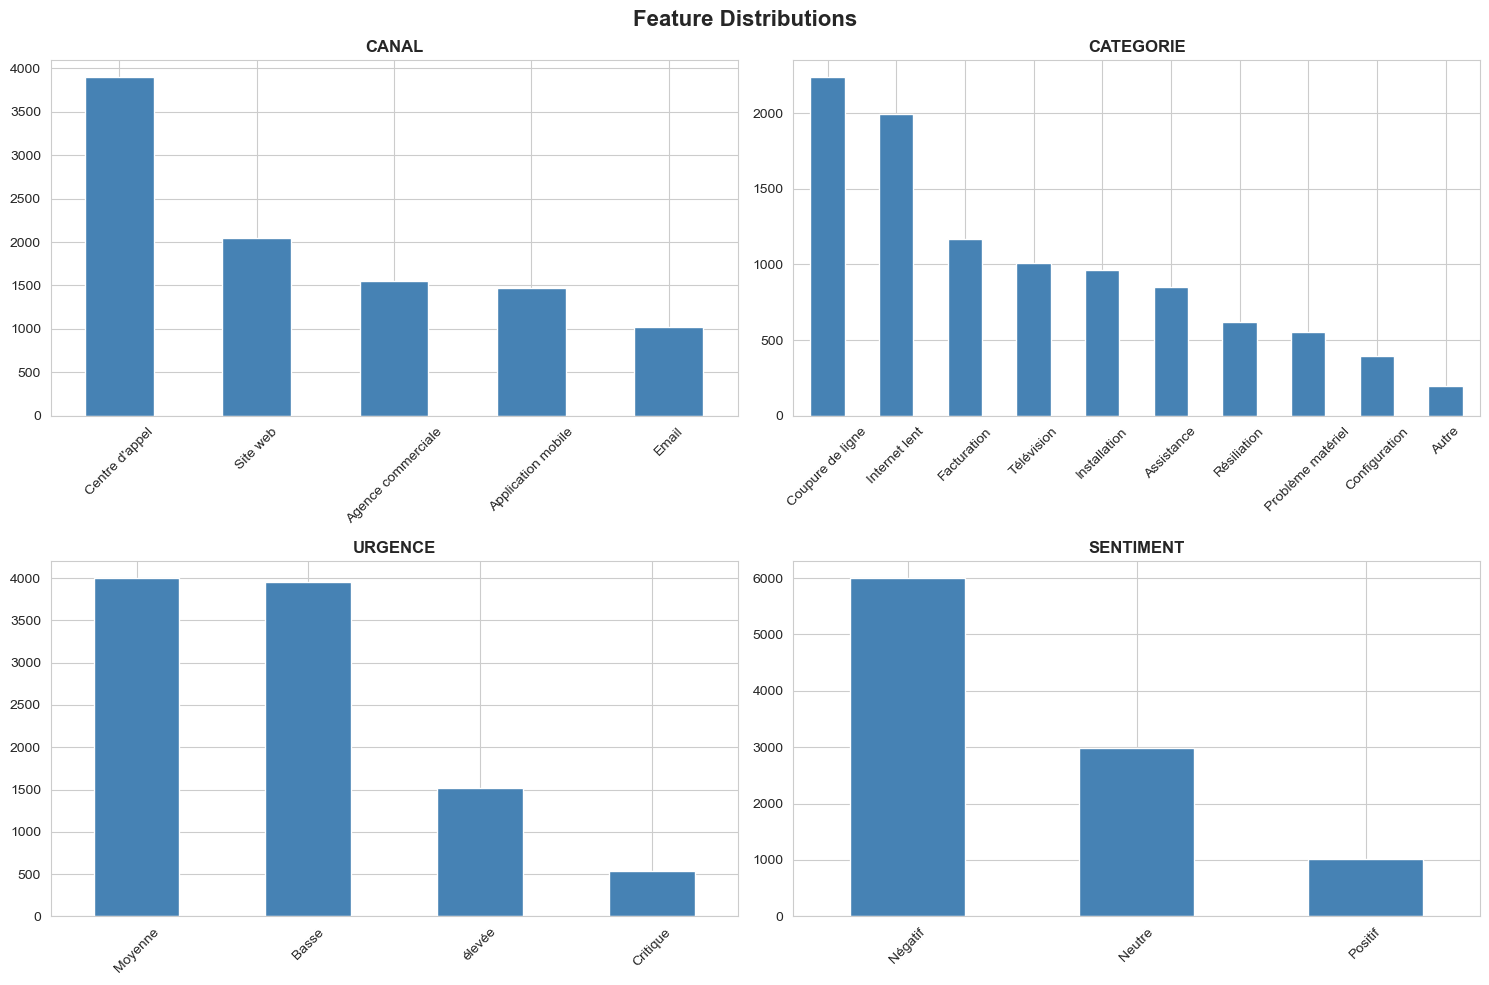

In [70]:
# Select features to analyze
FEATURES = ['canal', 'categorie', 'urgence', 'sentiment']
# Visualize distributions
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Feature Distributions', fontsize=16, fontweight='bold')

for idx, feature in enumerate(FEATURES):
    ax = axes[idx // 2, idx % 2]
    df[feature].value_counts().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'{feature.upper()}', fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3. Parameter Configuration

In [71]:

suggested_support = suggest_parameters(original_size, len(df))


MIN_SUPPORT = 100        
MIN_CONFIDENCE = 0.3    

print(f"\n Analysis Parameters:")
print(f"   Features: {FEATURES}")
print(f"   Min Support: {MIN_SUPPORT}")
print(f"   Min Confidence: {MIN_CONFIDENCE}")
print(f"   Suggested Support: {suggested_support}")


PARAMETER RECOMMENDATIONS

For 10,000 records:
  Conservative (fewer patterns):  min_support >= 200
  Balanced:                       min_support = 125
  Aggressive (more patterns):     min_support = 50

Confidence: 0.3-0.5 is typical (lower = more rules)

 Analysis Parameters:
   Features: ['canal', 'categorie', 'urgence', 'sentiment']
   Min Support: 100
   Min Confidence: 0.3
   Suggested Support: 125


## 4. Run FP-Growth Algorithm

In [72]:
# Prepare transactions
print(" Preparing transactions...")
transactions = prepare_data(df, FEATURES)
print(f" Created {len(transactions):,} transactions")

# Mine patterns
print("\n Mining frequent patterns...")
patterns = fp_growth(transactions, MIN_SUPPORT)
print(f" Found {len(patterns):,} frequent patterns")

# Generate association rules
print("\n Generating association rules...")
rules = generate_rules(patterns, MIN_CONFIDENCE, len(df))
print(f" Generated {len(rules):,} association rules")

 Preparing transactions...
 Created 10,000 transactions

 Mining frequent patterns...
 Found 277 frequent patterns

 Generating association rules...
 Generated 294 association rules


## 5. Analyze Results

In [73]:
# Display top patterns
print("="*80)
print("TOP 20 FREQUENT PATTERNS")
print("="*80)

sorted_patterns = sorted(patterns.items(), key=lambda x: x[1], reverse=True)[:20]
for i, (pattern, support) in enumerate(sorted_patterns, 1):
    pattern_str = ' → '.join(pattern)
    percentage = (support / len(df)) * 100
    print(f"{i:2d}. {pattern_str}")
    print(f"    Support: {support} ({percentage:.1f}%)\n")

TOP 20 FREQUENT PATTERNS
 1. sentiment=Négatif
    Support: 6003 (60.0%)

 2. urgence=Moyenne
    Support: 4004 (40.0%)

 3. urgence=Basse
    Support: 3953 (39.5%)

 4. canal=Centre d'appel
    Support: 3897 (39.0%)

 5. sentiment=Neutre
    Support: 2982 (29.8%)

 6. urgence=Moyenne → sentiment=Négatif
    Support: 2390 (23.9%)

 7. urgence=Basse → sentiment=Négatif
    Support: 2361 (23.6%)

 8. canal=Centre d'appel → sentiment=Négatif
    Support: 2338 (23.4%)

 9. categorie=Coupure de ligne
    Support: 2238 (22.4%)

10. canal=Site web
    Support: 2050 (20.5%)

11. categorie=Internet lent
    Support: 1995 (20.0%)

12. canal=Centre d'appel → urgence=Basse
    Support: 1563 (15.6%)

13. canal=Agence commerciale
    Support: 1553 (15.5%)

14. canal=Centre d'appel → urgence=Moyenne
    Support: 1539 (15.4%)

15. urgence=élevée
    Support: 1512 (15.1%)

16. canal=Application mobile
    Support: 1474 (14.7%)

17. categorie=Coupure de ligne → sentiment=Négatif
    Support: 1348 (13.5%

In [74]:
# Display top association rules
if rules: #its just a prettier printing 
    print("="*80)
    print("TOP 20 ASSOCIATION RULES (by Lift)")
    print("="*80)
    
    sorted_rules = sorted(rules, key=lambda x: x['lift'], reverse=True)[:20]
    for i, rule in enumerate(sorted_rules, 1):
        ant = ' ∧ '.join(rule['antecedent'])
        cons = ' ∧ '.join(rule['consequent'])
        print(f"{i:2d}. IF {ant}")
        print(f"    THEN {cons}")
        print(f"    Support: {rule['support']}, Confidence: {rule['confidence']:.1%}, Lift: {rule['lift']:.2f}\n")
else:
    print("  No rules found. Try lowering MIN_CONFIDENCE or MIN_SUPPORT.")

TOP 20 ASSOCIATION RULES (by Lift)
 1. IF categorie=Installation ∧ canal=Centre d'appel
    THEN sentiment=Neutre
    Support: 135, Confidence: 36.1%, Lift: 1.21

 2. IF canal=Agence commerciale ∧ categorie=Internet lent
    THEN sentiment=Neutre
    Support: 112, Confidence: 34.7%, Lift: 1.16

 3. IF categorie=Problème matériel ∧ urgence=Moyenne
    THEN canal=Centre d'appel
    Support: 105, Confidence: 45.3%, Lift: 1.16

 4. IF canal=Email ∧ urgence=Moyenne
    THEN sentiment=Neutre
    Support: 139, Confidence: 34.2%, Lift: 1.15

 5. IF categorie=Installation ∧ sentiment=Neutre
    THEN canal=Centre d'appel
    Support: 135, Confidence: 44.6%, Lift: 1.14

 6. IF categorie=Installation ∧ urgence=Basse
    THEN sentiment=Neutre
    Support: 135, Confidence: 34.1%, Lift: 1.14

 7. IF categorie=Installation ∧ canal=Centre d'appel
    THEN urgence=Basse
    Support: 169, Confidence: 45.2%, Lift: 1.14

 8. IF categorie=Facturation ∧ canal=Centre d'appel ∧ sentiment=Négatif
    THEN urgen

In [75]:
# Convert patterns to DataFrame for easier analysis
patterns_df = pd.DataFrame([
    {
        'pattern': ' → '.join(pattern),
        'length': len(pattern),
        'support': support,
        'support_pct': (support / len(df)) * 100
    }
    for pattern, support in patterns.items()
])

patterns_df = patterns_df.sort_values('support', ascending=False)
print("\n Patterns Summary:")
patterns_df.head(20)


 Patterns Summary:


,pattern,length,support,support_pct
276,sentiment=Négatif,1,6003,60.03
274,urgence=Moyenne,1,4004,40.04
272,urgence=Basse,1,3953,39.53
266,canal=Centre d'appel,1,3897,38.97
260,sentiment=Neutre,1,2982,29.82
275,urgence=Moyenne → sentiment=Négatif,2,2390,23.90
273,urgence=Basse → sentiment=Négatif,2,2361,23.61
271,canal=Centre d'appel → sentiment=Négatif,2,2338,23.38
242,categorie=Coupure de ligne,1,2238,22.38
226,canal=Site web,1,2050,20.50


In [76]:
# Convert rules to DataFrame
if rules:
    rules_df = pd.DataFrame([
        {
            'antecedent': ' ∧ '.join(rule['antecedent']),
            'consequent': ' ∧ '.join(rule['consequent']),
            'support': rule['support'],
            'confidence': rule['confidence'],
            'lift': rule['lift']
        }
        for rule in rules
    ])
    
    rules_df = rules_df.sort_values('lift', ascending=False)
    print("\n Rules Summary:")
    print(rules_df.head(10))
else:
    print("No rules to display")


 Rules Summary:
                                            antecedent            consequent  \
58       categorie=Installation ∧ canal=Centre d'appel      sentiment=Neutre   
168  canal=Agence commerciale ∧ categorie=Internet ...      sentiment=Neutre   
20       categorie=Problème matériel ∧ urgence=Moyenne  canal=Centre d'appel   
105                      canal=Email ∧ urgence=Moyenne      sentiment=Neutre   
57           categorie=Installation ∧ sentiment=Neutre  canal=Centre d'appel   
56              categorie=Installation ∧ urgence=Basse      sentiment=Neutre   
62       categorie=Installation ∧ canal=Centre d'appel         urgence=Basse   
131  categorie=Facturation ∧ canal=Centre d'appel ∧...         urgence=Basse   
132  categorie=Facturation ∧ urgence=Basse ∧ sentim...  canal=Centre d'appel   
19   categorie=Problème matériel ∧ canal=Centre d'a...       urgence=Moyenne   

     support  confidence      lift  
58       135    0.360963  1.210471  
168      112    0.346749  1.

## 6. Visualize Results

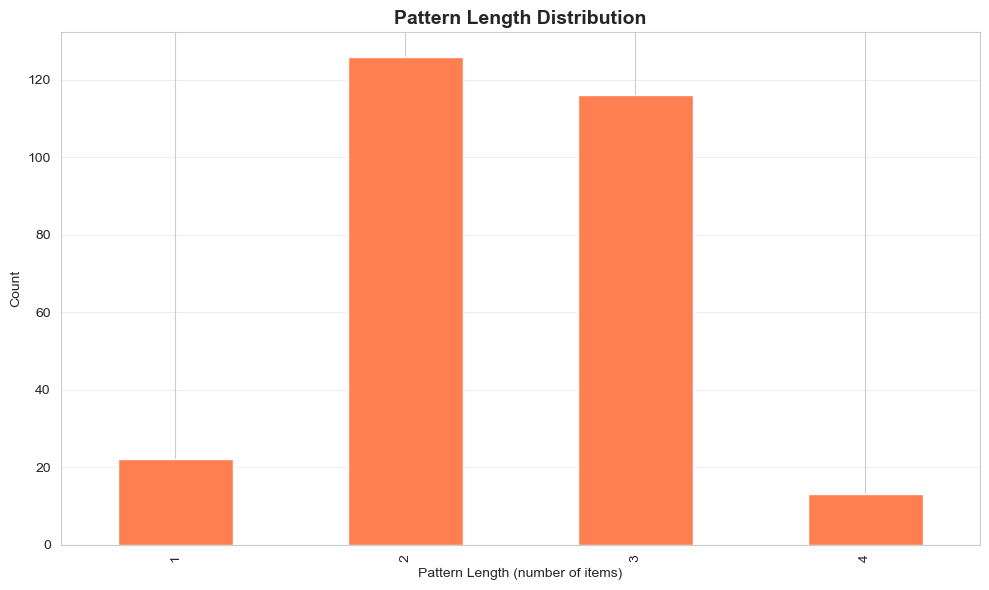

In [77]:
# Plot pattern length distribution
plt.figure(figsize=(10, 6))
patterns_df['length'].value_counts().sort_index().plot(kind='bar', color='coral')
plt.title('Pattern Length Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Pattern Length (number of items)')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

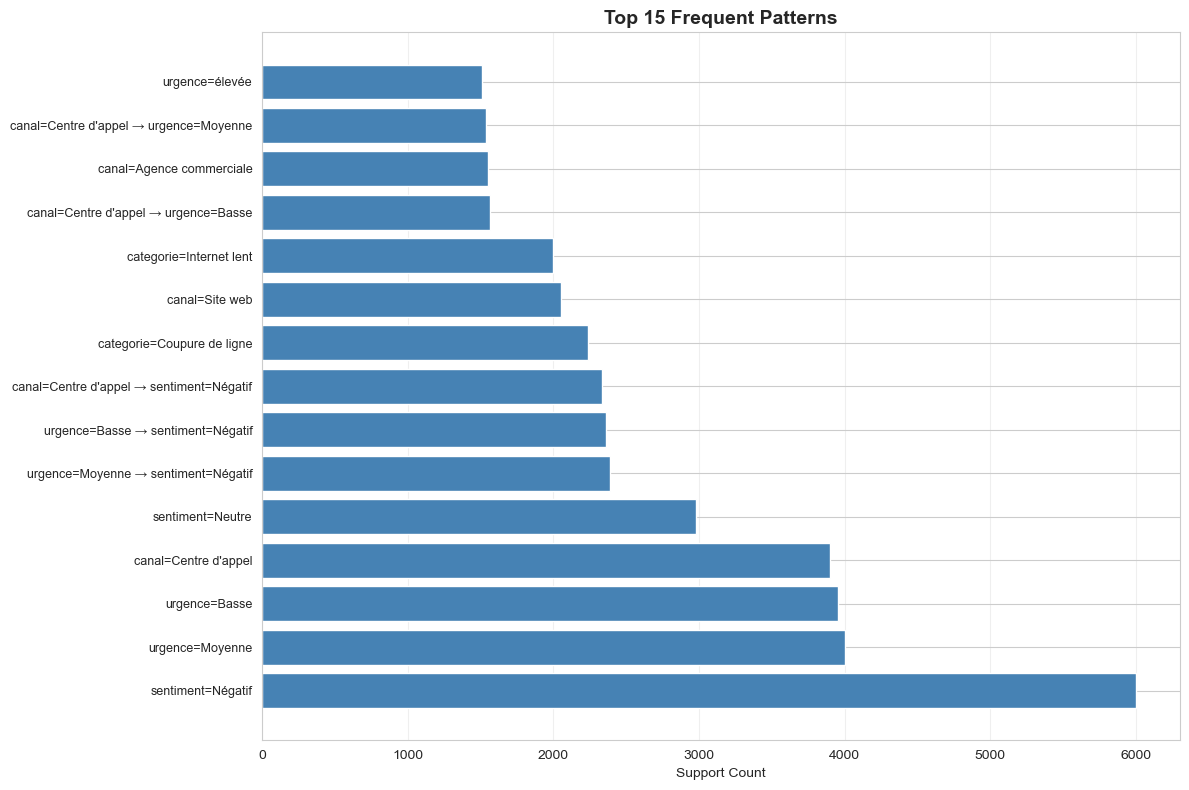

In [78]:
# Plot top 15 patterns by support
top_patterns = patterns_df.head(15)

plt.figure(figsize=(12, 8))
plt.barh(range(len(top_patterns)), top_patterns['support'], color='steelblue')
plt.yticks(range(len(top_patterns)), top_patterns['pattern'], fontsize=9)
plt.xlabel('Support Count')
plt.title('Top 15 Frequent Patterns', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

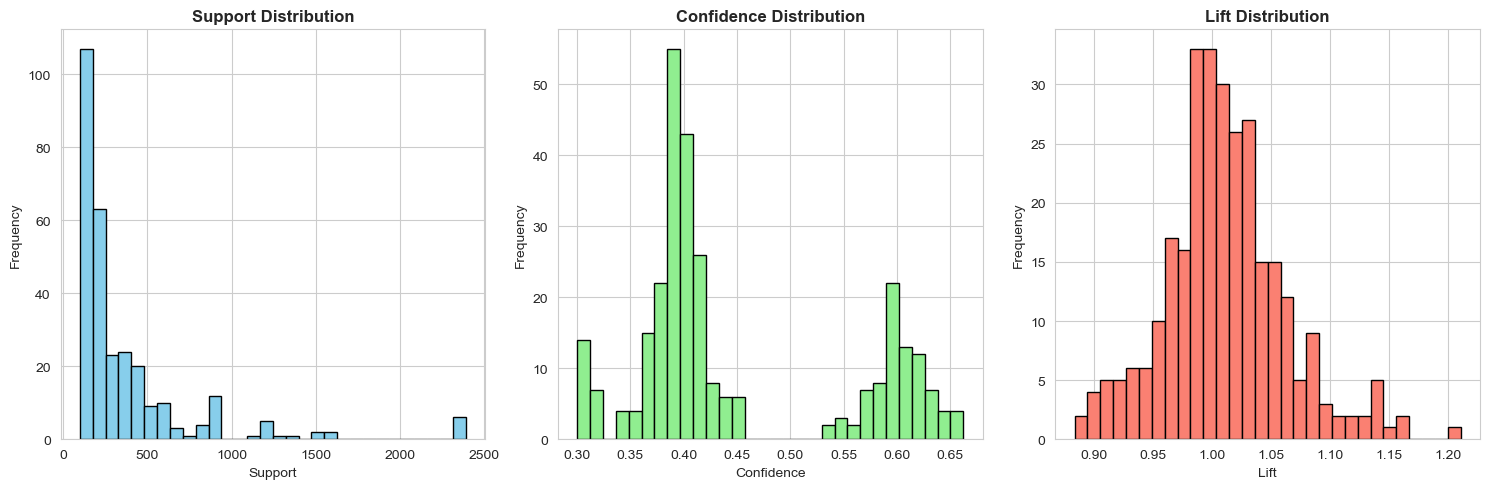

In [79]:
# Plot rules metrics if we have rules
if rules and len(rules) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Support distribution
    axes[0].hist(rules_df['support'], bins=30, color='skyblue', edgecolor='black')
    axes[0].set_title('Support Distribution', fontweight='bold')
    axes[0].set_xlabel('Support')
    axes[0].set_ylabel('Frequency')
    
    # Confidence distribution
    axes[1].hist(rules_df['confidence'], bins=30, color='lightgreen', edgecolor='black')
    axes[1].set_title('Confidence Distribution', fontweight='bold')
    axes[1].set_xlabel('Confidence')
    axes[1].set_ylabel('Frequency')
    
    # Lift distribution
    axes[2].hist(rules_df['lift'], bins=30, color='salmon', edgecolor='black')
    axes[2].set_title('Lift Distribution', fontweight='bold')
    axes[2].set_xlabel('Lift')
    axes[2].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()
else:
    print("No rules to visualize")

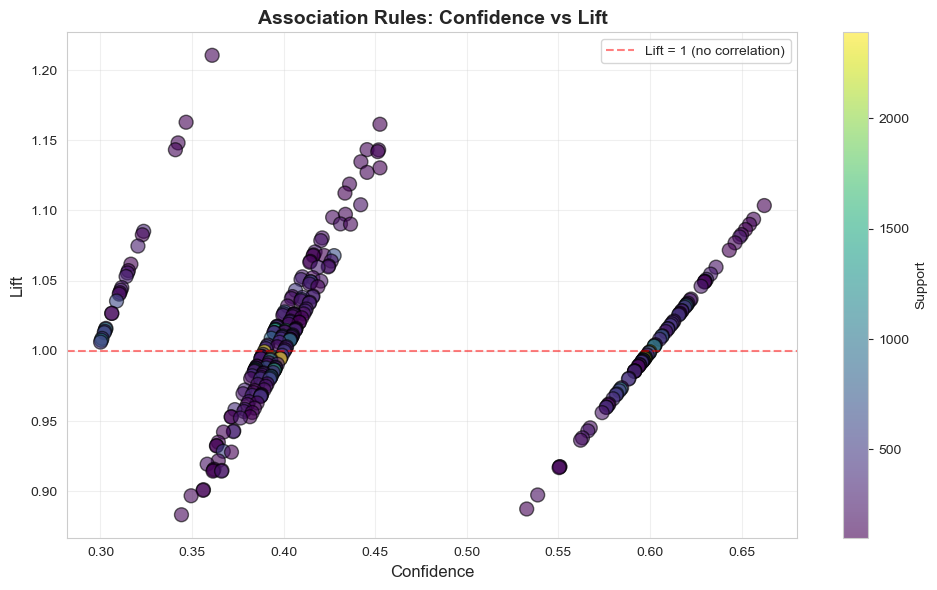

In [80]:
# Scatter plot : Confidence vs Lift for rules
if rules and len(rules) > 0:
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(rules_df['confidence'], rules_df['lift'], 
                         c=rules_df['support'], s=100, alpha=0.6, 
                         cmap='viridis', edgecolors='black')
    plt.colorbar(scatter, label='Support')
    plt.xlabel('Confidence', fontsize=12)
    plt.ylabel('Lift', fontsize=12)
    plt.title('Association Rules: Confidence vs Lift', fontsize=14, fontweight='bold')
    plt.axhline(y=1, color='r', linestyle='--', alpha=0.5, label='Lift = 1 (no correlation)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No rules to visualize")

## 7. Filter and Analyze Specific Patterns

In [81]:
# Find patterns containing specific items
search_term = "canal=Centre d'appel"

matching_patterns = patterns_df[patterns_df['pattern'].str.contains(search_term, case=False)]
print(f"\n Patterns containing '{search_term}':")
print(f"Found {len(matching_patterns)} patterns\n")
matching_patterns.head(20)


 Patterns containing 'canal=Centre d'appel':
Found 63 patterns



,pattern,length,support,support_pct
266,canal=Centre d'appel,1,3897,38.97
271,canal=Centre d'appel → sentiment=Négatif,2,2338,23.38
269,canal=Centre d'appel → urgence=Basse,2,1563,15.63
267,canal=Centre d'appel → urgence=Moyenne,2,1539,15.39
263,sentiment=Neutre → canal=Centre d'appel,2,1180,11.80
270,canal=Centre d'appel → urgence=Basse → sentime...,3,934,9.34
268,canal=Centre d'appel → urgence=Moyenne → senti...,3,919,9.19
249,categorie=Coupure de ligne → canal=Centre d'appel,2,880,8.80
219,categorie=Internet lent → canal=Centre d'appel,2,799,7.99
181,urgence=élevée → canal=Centre d'appel,2,591,5.91


In [82]:
# Find high-lift rules (strong correlations)
if rules and len(rules) > 0:
    high_lift_rules = rules_df[rules_df['lift'] > 1.15]
    print(f"\n High-Lift Rules (Lift > 1.15):")
    print(f"Found {len(high_lift_rules)} strong rules\n")
    print(high_lift_rules.head(20))
else:
    print("No rules available")


 High-Lift Rules (Lift > 1.15):
Found 3 strong rules

                                            antecedent            consequent  \
58       categorie=Installation ∧ canal=Centre d'appel      sentiment=Neutre   
168  canal=Agence commerciale ∧ categorie=Internet ...      sentiment=Neutre   
20       categorie=Problème matériel ∧ urgence=Moyenne  canal=Centre d'appel   

     support  confidence      lift  
58       135    0.360963  1.210471  
168      112    0.346749  1.162808  
20       105    0.452586  1.161371  


In [83]:
# Find rules with high confidence
if rules and len(rules) > 0:
    high_conf_rules = rules_df[rules_df['confidence'] > 0.4]
    print(f"\n High-Confidence Rules (Confidence > 40%):")
    print(f"Found {len(high_conf_rules)} reliable rules\n")
    print(high_conf_rules.head(20))
else:
    print("No rules available")


 High-Confidence Rules (Confidence > 40%):
Found 163 reliable rules

                                            antecedent            consequent  \
20       categorie=Problème matériel ∧ urgence=Moyenne  canal=Centre d'appel   
57           categorie=Installation ∧ sentiment=Neutre  canal=Centre d'appel   
62       categorie=Installation ∧ canal=Centre d'appel         urgence=Basse   
131  categorie=Facturation ∧ canal=Centre d'appel ∧...         urgence=Basse   
132  categorie=Facturation ∧ urgence=Basse ∧ sentim...  canal=Centre d'appel   
19   categorie=Problème matériel ∧ canal=Centre d'a...       urgence=Moyenne   
55           categorie=Installation ∧ sentiment=Neutre         urgence=Basse   
22     categorie=Problème matériel ∧ sentiment=Négatif  canal=Centre d'appel   
195  categorie=Internet lent ∧ sentiment=Neutre ∧ u...  canal=Centre d'appel   
177        canal=Agence commerciale ∧ sentiment=Neutre       urgence=Moyenne   
73               categorie=Télévision ∧ urgence=él

## 8. Export Results

In [84]:
# Save patterns to CSV
patterns_df.to_csv('fpgrowth_patterns.csv', index=False)
print(" Patterns saved to: fpgrowth_patterns.csv")

# Save rules to CSV
if rules and len(rules) > 0:
    rules_df.to_csv('fpgrowth_rules.csv', index=False)
    print(" Rules saved to: fpgrowth_rules.csv")

 Patterns saved to: fpgrowth_patterns.csv
 Rules saved to: fpgrowth_rules.csv


In [85]:
# Generate HTML report
print(" Generating HTML report...")
output_file = generate_html_report(
    patterns=patterns,
    rules=rules,
    total_records=original_size,
    analyzed_records=len(df),
    output_filename='fpgrowth_results.html'
)
print(f" HTML report saved to: {output_file}")

# Open in browser
import webbrowser
import os
webbrowser.open('file://' + os.path.abspath(output_file))

 Generating HTML report...
 HTML report saved to: fpgrowth_results.html


True

## 9. Summary Statistics

In [86]:
# Print final summary
print("="*80)
print("ANALYSIS SUMMARY")
print("="*80)
print(f"\nDataset:")
print(f"  Original records: {original_size:,}")
print(f"  Analyzed records: {len(df):,}")
print(f"  Features: {', '.join(FEATURES)}")
print(f"\nParameters:")
print(f"  Min Support: {MIN_SUPPORT}")
print(f"  Min Confidence: {MIN_CONFIDENCE}")
print(f"\nResults:")
print(f"  Frequent Patterns: {len(patterns):,}")
print(f"  Association Rules: {len(rules):,}")
print(f"\nPattern Lengths:")
print(patterns_df['length'].value_counts().sort_index())

if rules and len(rules) > 0:
    print(f"\nRule Statistics:")
    print(f"  Avg Confidence: {rules_df['confidence'].mean():.2%}")
    print(f"  Avg Lift: {rules_df['lift'].mean():.2f}")
    print(f"  Max Lift: {rules_df['lift'].max():.2f}")
    print(f"  Rules with Lift > 1.1: {len(rules_df[rules_df['lift'] > 1.1])}")

print("\n" + "="*80)

ANALYSIS SUMMARY

Dataset:
  Original records: 100,000
  Analyzed records: 10,000
  Features: canal, categorie, urgence, sentiment

Parameters:
  Min Support: 100
  Min Confidence: 0.3

Results:
  Frequent Patterns: 277
  Association Rules: 294

Pattern Lengths:
length
1     22
2    126
3    116
4     13
Name: count, dtype: int64

Rule Statistics:
  Avg Confidence: 44.93%
  Avg Lift: 1.01
  Max Lift: 1.21
  Rules with Lift > 1.1: 15



## 10. Custom Analysis 

In [87]:
# Trying different parameters
def quick_analysis(features, min_support, min_confidence):
    """Run FP-Growth with custom parameters"""
    transactions = prepare_data(df, features)
    patterns = fp_growth(transactions, min_support)
    rules = generate_rules(patterns, min_confidence, len(df))
    
    print(f"\n Results with Support={min_support}, Confidence={min_confidence}:")
    print(f"   Patterns: {len(patterns)}")
    print(f"   Rules: {len(rules)}")
    
    return patterns, rules



In [88]:
# Experiment with different feature combinations
feature_combinations = [
    ['canal', 'categorie'],
    ['canal', 'urgence'],
    ['categorie', 'sentiment'],
    ['urgence', 'status'],
    ['canal', 'categorie', 'urgence'],
]

print(" Testing different feature combinations...\n")
for features in feature_combinations:
    transactions = prepare_data(df, features)
    patterns = fp_growth(transactions, MIN_SUPPORT)
    rules = generate_rules(patterns, MIN_CONFIDENCE, len(df))
    print(f"{', '.join(features):40s} → Patterns: {len(patterns):4d}, Rules: {len(rules):4d}")

 Testing different feature combinations...

canal, categorie                         → Patterns:   51, Rules:    9
canal, urgence                           → Patterns:   26, Rules:   14
categorie, sentiment                     → Patterns:   35, Rules:   15
urgence, status                          → Patterns:   25, Rules:   17
canal, categorie, urgence                → Patterns:  125, Rules:   81
